<h2 style='color: orange'># Feature Scaling</h2>

<p style='color: pink'>It is a technique to standardize the independent features present in the data in a fixed range</p>

<h4 style='color: brown'># Why do we need Feature Scaling</h4>

<p style='color: pink'>Data in some cols vary in vast range and when we plot them together, they reduce the performance of model</p>

<h4 style='color: brown'># Types of Feature Scaling</h4>

<p style='color: pink'>a. Standardization</p>
<p style='color: pink'>b. Normalization  --> 3 Main technique: MinmaxScaler, MaxAbsScaling, RobustScaler</p>

<h2 style='color: green'>Standardizatn</h2>
<p style='color: sky-blue'>It is also called as Z-score Normalizatn</p>
<p style='color: sky-blue'>In this we calculate the standardize col of an existing col by using this formula:</p>
<p style='color: sky-blue'>Formula : </p>
<p style='color: sky-blue'>xi = (xi - x^) / ~ </p>
<p style='color: sky-blue'>Here: xi = existing val,
x^ = mean val,
~ = standard deviatn</p>
<p style='color: brown'># Now after calculating new values, the new mean is 0 and new S.D is 1</p>
<p style='color: brown'># It means all value are shifts from their originl positn to around (0,0) as their mean become 0 and their S.D is between (1,1) for both cols/axis</p>

- There is no harm by doing standardizatn on data as it will increase accuracy but not decrease it 

- there is no impact of standardizatn on the outliers and we need to deal we them separately

<h4 style='color: brown'># When to use Standardizatn</h4>
- Always use where we are calculating distance
<p style='color: orange'>Use it in these algos:</p>
<p style='color: pink'>1. K-Means</p>
<p style='color: pink'>2. K-Nearest-Neighbor(KNN)</p>
<p style='color: pink'>3. Principal Component Analysis(PCA)</p>
<p style='color: pink'>4. Artifical Neural Network</p>
<p style='color: pink'>5. Gradient Descent</p>
<p style='color: orange'>Don't use it in these algos</p>
<p style='color: pink'>Decision Tree, Random Forest, Gradient Boost, Xg boost</p>

# Example

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\Social_Network_Ads.csv')

In [4]:
df = df.iloc[:,2:]

In [5]:
df.sample(3)

,Age,EstimatedSalary,Purchased
255,52,90000,1
20,45,22000,1
139,19,25000,0


In [7]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased',axis=1), df['Purchased'], test_size=0.3, random_state=0)
print(x_train.shape, x_test.shape)

(280, 2) (120, 2)


In [11]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# always fit only train data for learning para
scaler.fit(x_train)

# transform 
# train & test data
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

- This transformatn will create numpy arr, so we need to convert it into pandas df for feeding into model

In [12]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [14]:
np.round(x_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


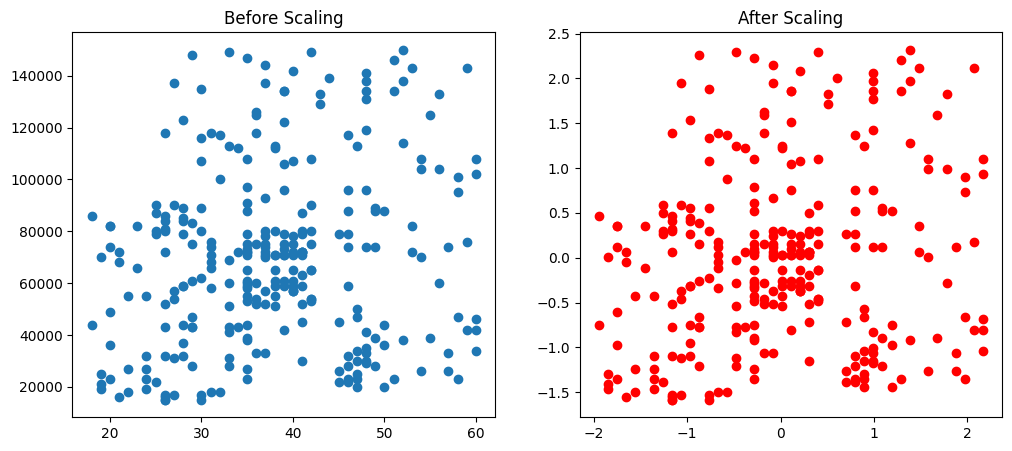

In [15]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], color='red')
ax2.set_title('After Scaling')
plt.show()

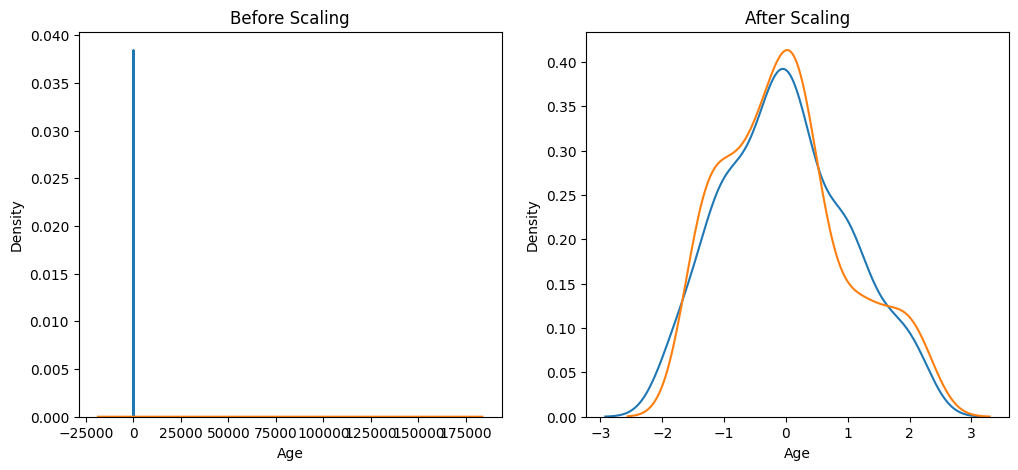

In [17]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

# before
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)
# after
ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model = LogisticRegression()
model_scaled = LogisticRegression()

In [20]:
model.fit(x_train, y_train)
model_scaled.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
from sklearn.metrics import accuracy_score

In [23]:
y_pred = model.predict(x_test)
y_pred_scal = model_scaled.predict(x_test_scaled)

In [24]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scal))

Actual 0.875
Scaled 0.8666666666666667


<h2 style='color: green'>Normalization</h2>
<p style='color: pink'>It is a technique often applied as part of data preparatn for ml. The goal of normalizatn is to change the vals of numeric cols in the dataset to use a common scale, without distorting differences in the range of vals or losing informatn</p>
<p style='color: pink'>Its core aim is to eliminate the units of data and only deal with magnitude of data for better outcomes</p>
<h5 style='color: brown'># Types of Normalizatn</h5>
<p style='color: pink'>a. MinMaxScaling</p>
<p style='color: pink'>b. Mean Normalizatn</p>
<p style='color: pink'>c. Max Absolute Scaling</p>
<p style='color: pink'>d. Robust Scaling</p>

<h4 style='color: red'>MinMaxScaling</h4>

<p style='color:pink'>Scales features to a fixed range, usually 0 to 1.</p>
<p style='color: pink'>Formula :</p>
<p style='color: pink'> Xi' = (Xi - Xmin) / (Xmax - Xmin)</p>
<p style='color: pink'>It's value lies b/w 0 & 1</p>
<p style='color: pink'>Geometric Intuition : We are squizing all the values distributn from its original positn to coordinates (1,1)</p>

<h4 style='color: red'>Mean Normalizatn</h4>
<p style='color: pink'>Formula :</p>
<p style='color: pink'>Xi' = (Xi - Xmean) / (Xmax - Xmin)</p>
<p style='color: pink'>Here we are doing the values to Mean Centric</p>
<p style='color: pink'>There is no built-in code for this And it is used for Centric data</p>

<h4 style='color: red'>MaxAbsScaling</h4>
<p style='color:pink'>Scales features by dividing by the maximum absolute value, bringing values into the range [-1, 1] without shifting the mean.</p>
<p style='color: pink'>Formula :</p>
<p style='color: pink'>Xi' = Xi / abs(Xmax)</p>
<p style='color: pink'>Scikit has built-in class called MaxAbsScaler for this</p>
<p style='color: pink'>It is used for sparse data(contains more 0's)</p>

<h4 style='color: red'>Robust Scaling</h4>
<p style='color:pink'>Scales features using the median and interquartile range (IQR), so it is robust to outliers.</p>
<p style='color: pink'>Formula :</p>
<p style='color: pink'>Xi' = (Xi - Xmedian) / IQR(75th percentile - 25th percentile)</p>
<p style='color: pink'>Robust to Outliers</p>

<h4 style='color: red'>When to use Normalizatn</h4>
- When we already Know about min and max values of data

# Example

In [28]:
dafr = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\wine_data.csv', header=None, usecols=[0,1,2])
dafr.columns=['Class label', 'Alcohol', 'Malic acid']

In [29]:
dafr.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

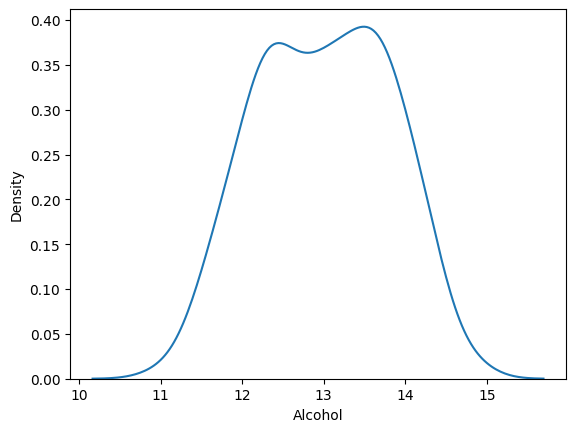

In [30]:
sns.kdeplot(dafr['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

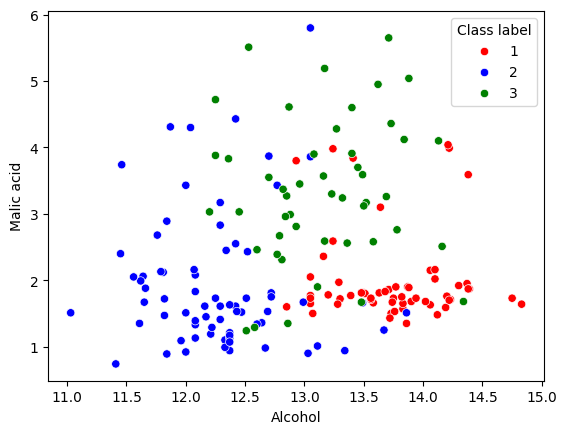

In [33]:
color_dict = {1:'red', 2:'blue', 3:'green'}
sns.scatterplot(x=dafr['Alcohol'], y=dafr['Malic acid'], hue=dafr['Class label'], palette=color_dict)  # here palette allow to write our own color palete

In [35]:
# Train test split
from sklearn.model_selection import train_test_split
x_tr, x_ts, y_tr, y_ts = train_test_split(dafr.drop('Class label',axis=1), dafr['Class label'], test_size=0.3, random_state=0)
print(x_tr.shape, x_ts.shape)

(124, 2) (54, 2)


In [36]:
from sklearn.preprocessing import MinMaxScaler

scal = MinMaxScaler()

# fit train data
scal.fit(x_tr)
# transform tr & ts
x_tr_sc = scal.transform(x_tr)
x_ts_sc = scal.transform(x_ts)


In [37]:
x_tr_sc = pd.DataFrame(x_tr_sc, columns=x_tr.columns)
x_ts_sc = pd.DataFrame(x_ts_sc, columns=x_ts.columns)

In [39]:
np.round(x_tr.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


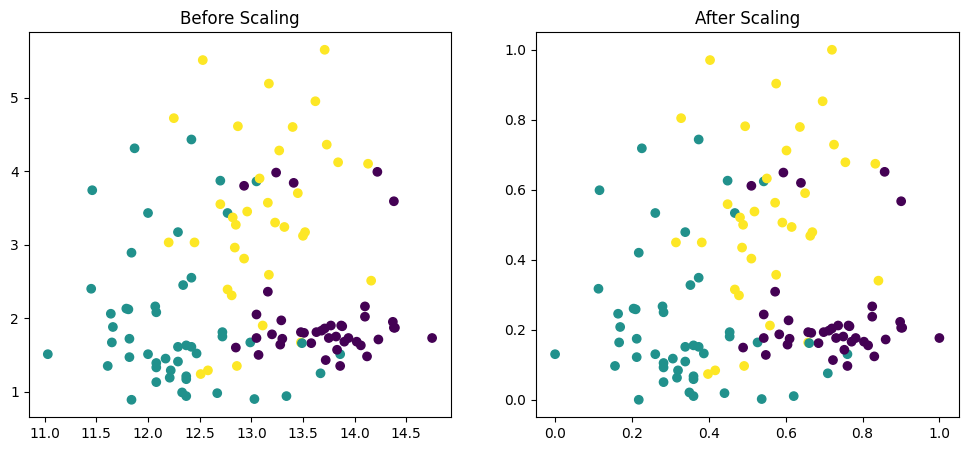

In [42]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_tr['Alcohol'], x_tr['Malic acid'], c=y_tr)
ax1.set_title('Before Scaling')
ax2.scatter(x_tr_sc['Alcohol'], x_tr_sc['Malic acid'], c=y_tr)
ax2.set_title('After Scaling')
plt.show()

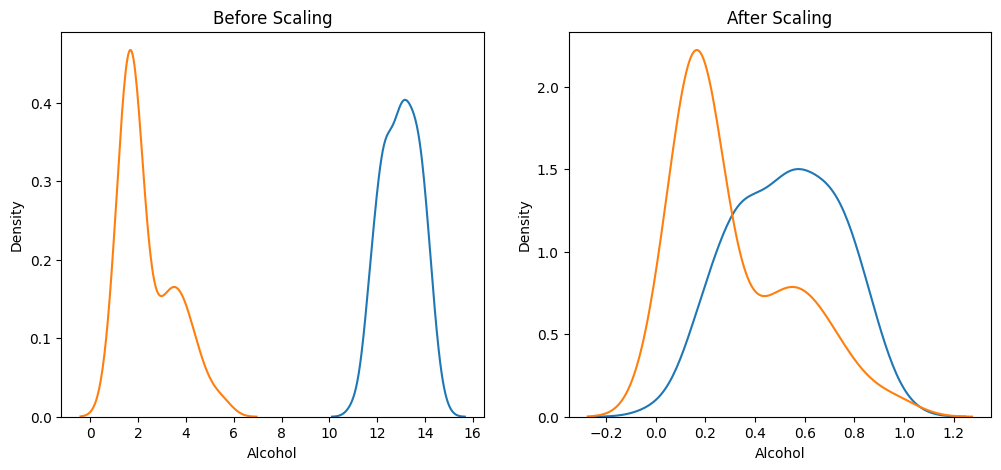

In [43]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

# before
ax1.set_title('Before Scaling')
sns.kdeplot(x_tr['Alcohol'], ax=ax1)
sns.kdeplot(x_tr['Malic acid'], ax=ax1)
# after
ax2.set_title('After Scaling')
sns.kdeplot(x_tr_sc['Alcohol'], ax=ax2)
sns.kdeplot(x_tr_sc['Malic acid'], ax=ax2)

plt.show()